<a href="https://colab.research.google.com/github/jellybbie/study/blob/project3/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the Excel file
df = pd.read_excel('/content/salt_invitro1.xlsx', engine='openpyxl')

# Display the first 5 rows and column information
display(df.head())
print(df.info())

,No,Type,Strain,TSB,TSB.1,TSB.2,TSB+NaCl,TSB+NaCl.1,TSB+NaCl.2,YPDB,...,YPDB.2,YPDB+NaCl,YPDB+NaCl.1,YPDB+NaCl.2,MRS,MRS.1,MRS.2,MRS+NaCl,MRS+NaCl.1,MRS+NaCl.2
0,1,Bacteria,1R-RH9-M1-A6,1.068,1.769,1.543,1.357,1.186,1.770,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Bacteria,1R-RH9-M1-B2,1.076,1.143,1.098,1.218,1.185,1.217,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Bacteria,1R-RH9-M1-B3,1.068,1.130,1.092,1.162,1.179,1.185,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Bacteria,2R-RH6-M1-F5,1.104,1.140,1.068,1.261,1.168,1.188,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Bacteria,2R-RH6-M1-F6,1.078,1.189,1.179,1.228,1.215,1.245,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   No           246 non-null    int64  
 1   Type         246 non-null    object 
 2   Strain       246 non-null    object 
 3   TSB          53 non-null     float64
 4   TSB.1        53 non-null     float64
 5   TSB.2        53 non-null     float64
 6   TSB+NaCl     53 non-null     float64
 7   TSB+NaCl.1   53 non-null     float64
 8   TSB+NaCl.2   53 non-null     float64
 9   YPDB         0 non-null      float64
 10  YPDB.1       0 non-null      float64
 11  YPDB.2       0 non-null      float64
 12  YPDB+NaCl    0 non-null      float64
 13  YPDB+NaCl.1  0 non-null      float64
 14  YPDB+NaCl.2  0 non-null      float64
 15  MRS          0 non-null      float64
 16  MRS.1        0 non-null      float64
 17  MRS.2        0 non-null      float64
 18  MRS+NaCl     0 non-null      float64
 19  MRS+NaCl

In [7]:
bacteria_df = df[df['Type'] == 'Bacteria'].copy()

# Create a list to store data for the new long format DataFrame
long_data = []

# Iterate through each row of the bacteria_df
for index, row in bacteria_df.iterrows():
    strain = row['Strain']
    # Define TSB and TSB+NaCl column names for each replicate
    tsb_cols_for_reps = ['TSB', 'TSB.1', 'TSB.2']
    tsb_nacl_cols_for_reps = ['TSB+NaCl', 'TSB+NaCl.1', 'TSB+NaCl.2']

    for i in range(3): # For 3 replicates
        tsb_od = row[tsb_cols_for_reps[i]]
        tsb_nacl_od = row[tsb_nacl_cols_for_reps[i]]

        # Calculate the ratio for this specific replicate
        # Handle division by zero or missing values. Consider NaN as missing.
        if pd.notna(tsb_od) and tsb_od != 0 and pd.notna(tsb_nacl_od):
            normalized_od_rep = tsb_nacl_od / tsb_od
        else:
            normalized_od_rep = float('nan') # Set to NaN if invalid

        long_data.append({
            'Strain': strain,
            'Replicate': i,
            'TSB_OD': tsb_od,
            'TSB_NaCl_OD': tsb_nacl_od,
            'Normalized_OD_Replicate': normalized_od_rep
        })

# Create a DataFrame from the long_data, dropping rows with NaN in Normalized_OD_Replicate
replicate_df = pd.DataFrame(long_data).dropna(subset=['Normalized_OD_Replicate'])

# Now, calculate the mean and standard deviation of 'Normalized_OD_Replicate' per strain
plot_df = replicate_df.groupby('Strain')['Normalized_OD_Replicate'].agg(
    mean_normalized_od='mean',
    std_normalized_od='std'
).reset_index()

# For strains with only one valid replicate, std will be NaN. Fill with 0 for plotting.
plot_df['std_normalized_od'] = plot_df['std_normalized_od'].fillna(0)

display(plot_df.head())
print(plot_df.info())

,Strain,mean_normalized_od,std_normalized_od
0,1R-RH9-M1-A6,1.052447,0.207177
1,1R-RH9-M1-B2,1.092365,0.049591
2,1R-RH9-M1-B3,1.072181,0.024998
3,2R-RH6-M1-F5,1.093044,0.061157
4,2R-RH6-M1-F6,1.072331,0.060325


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Strain              52 non-null     object 
 1   mean_normalized_od  52 non-null     float64
 2   std_normalized_od   52 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.3+ KB
None


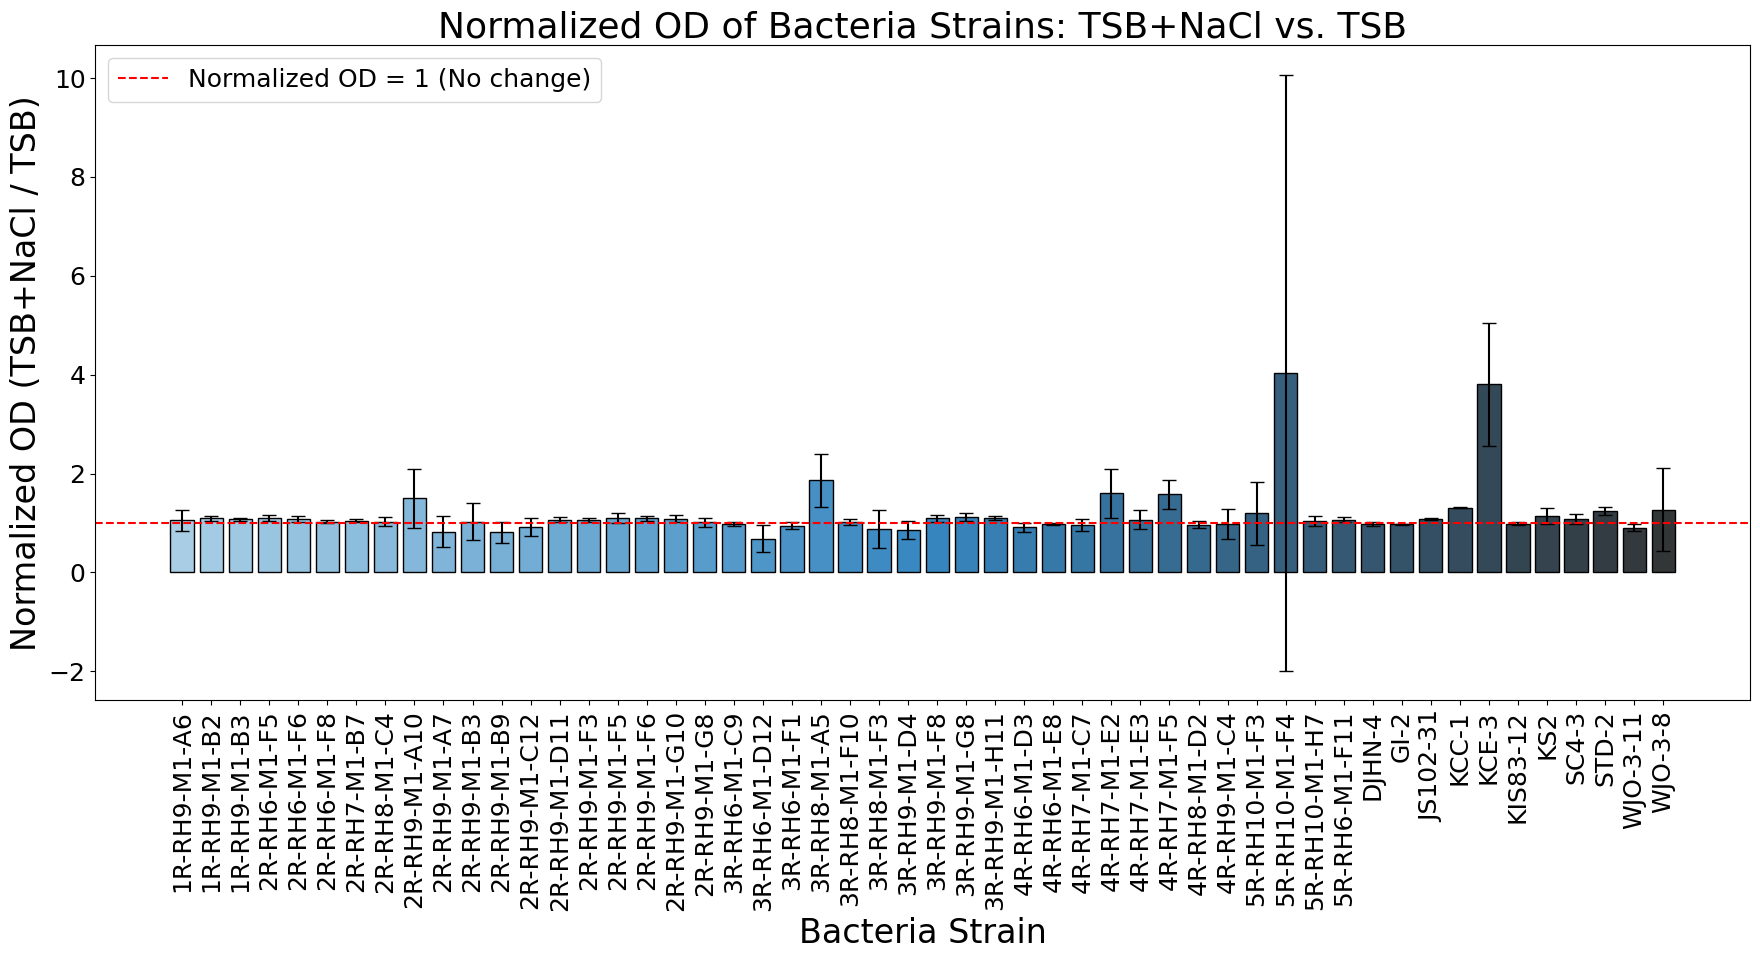

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Increase the default font size for all text elements
plt.rcParams.update({'font.size': 20}) # Set a base font size, adjust as needed

plt.figure(figsize=(18, 10)) # Adjust figure size for larger fonts

# Get x-axis positions for the bars
x_pos = np.arange(len(plot_df['Strain']))

# Get colors from a Seaborn palette (to maintain consistency)
# We need to explicitly assign colors since we are not using sns.barplot's internal color mapping
colors = sns.color_palette('Blues_d', n_colors=len(plot_df['Strain']))

# Plot bars and error bars separately using matplotlib.pyplot.bar
# This gives explicit control and avoids the yerr shape mismatch issue
plt.bar(
    x_pos,
    plot_df['mean_normalized_od'],
    yerr=plot_df['std_normalized_od'],
    color=colors,
    edgecolor='black', # Set bar outline color to black
    ecolor='black', # Set error bar color to black
    capsize=5, # Add caps to the error bars for better visibility
    width=0.8 # Adjust bar width if needed
)

# Set x-axis labels with strain names and rotate them
plt.xticks(x_pos, plot_df['Strain'], rotation=90, fontsize=18) # Specific font size for x-tick labels
plt.yticks(fontsize=18) # Specific font size for y-tick labels

plt.axhline(1, color='red', linestyle='--', label='Normalized OD = 1 (No change)')
plt.xlabel('Bacteria Strain', fontsize=24) # Specific font size for x-label
plt.ylabel('Normalized OD (TSB+NaCl / TSB)', fontsize=24) # Specific font size for y-label
plt.title('Normalized OD of Bacteria Strains: TSB+NaCl vs. TSB', fontsize=26) # Specific font size for title
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

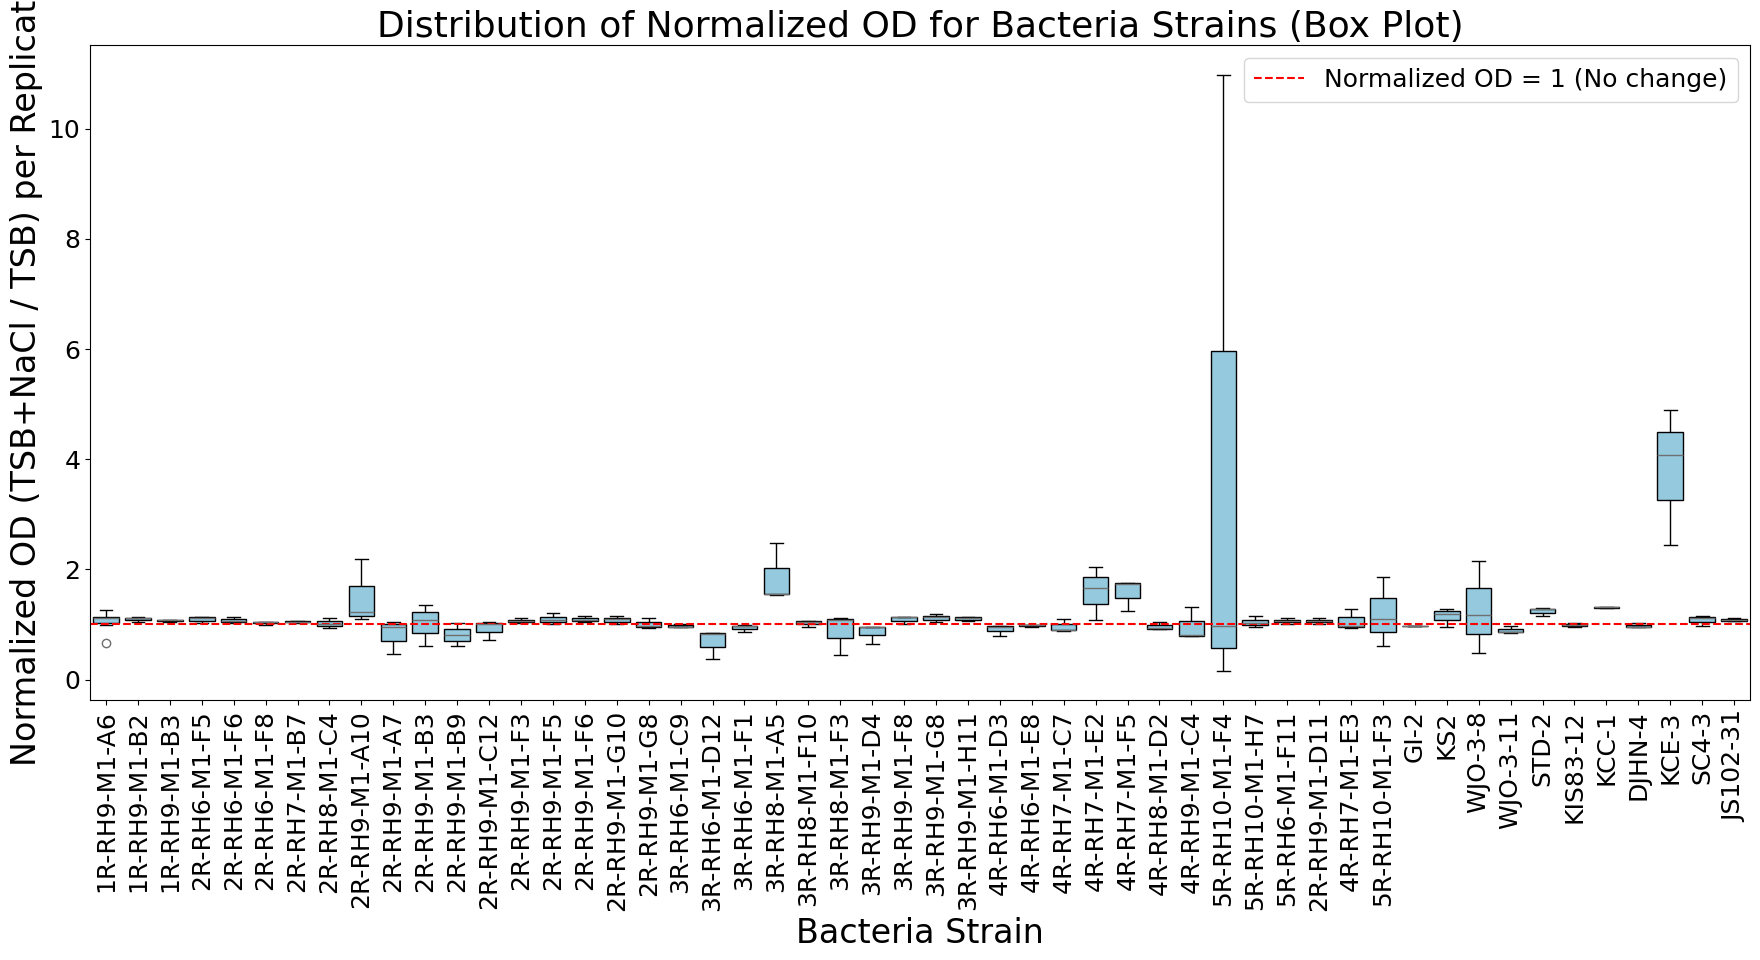

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Increase the default font size for all text elements
plt.rcParams.update({'font.size': 20}) # Set a base font size, adjust as needed

plt.figure(figsize=(18, 10)) # Adjust figure size for larger fonts
sns.boxplot(
    x='Strain',
    y='Normalized_OD_Replicate',
    data=replicate_df, # Use the replicate_df for individual replicate values
    color='skyblue', # Use a single color for consistency
    boxprops=dict(edgecolor='black'), # Set box outline color to black
    whiskerprops=dict(color='black'), # Set whisker (error bar) color to black
    capprops=dict(color='black') # Set cap (error bar end) color to black
)

plt.axhline(1, color='red', linestyle='--', label='Normalized OD = 1 (No change)')
plt.xlabel('Bacteria Strain', fontsize=24) # Specific font size for x-label
plt.ylabel('Normalized OD (TSB+NaCl / TSB) per Replicate', fontsize=24) # Specific font size for y-label
plt.title('Distribution of Normalized OD for Bacteria Strains (Box Plot)', fontsize=26) # Specific font size for title
plt.xticks(rotation=90, fontsize=18) # Specific font size for x-tick labels
plt.yticks(fontsize=18) # Specific font size for y-tick labels
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()